In [1]:
#importing all required python libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn import metrics 
import seaborn as sns
import matplotlib.pyplot as plt #use to visualize dataset values
import os
import joblib

In [2]:
#loading and displaying hospital stay icu dataset
dataset = pd.read_csv("Dataset/LengthOfStay.csv", nrows=2000)
dataset

,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,...,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
0,1,8/29/2012,0,F,0,0,0,0,0,0,...,192.476918,12.0,1.390722,30.432418,96,6.5,4,9/1/2012,B,0
1,2,5/26/2012,5+,F,0,0,0,0,0,0,...,94.078507,8.0,0.943164,28.460516,61,6.5,1,6/2/2012,A,1
2,3,9/22/2012,1,F,0,0,0,0,0,0,...,130.530524,12.0,1.065750,28.843812,64,6.5,2,9/25/2012,B,0
3,4,8/9/2012,0,F,0,0,0,0,0,0,...,163.377028,12.0,0.906862,27.959007,76,6.5,1,8/10/2012,A,0
4,5,12/20/2012,0,F,0,0,0,1,0,1,...,94.886654,11.5,1.242854,30.258927,67,5.6,2,12/24/2012,E,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,11/18/2012,2,M,1,0,1,0,0,0,...,61.560195,30.0,0.941336,27.621422,60,5.3,1,11/26/2012,E,1
1996,1997,2/21/2012,0,M,1,0,0,0,0,0,...,165.808034,19.0,1.377759,29.148367,70,6.5,1,2/24/2012,E,0
1997,1998,1/19/2012,1,F,0,0,0,0,0,0,...,115.590613,12.0,0.930608,31.128404,85,6.5,3,1/21/2012,A,0
1998,1999,3/6/2012,4,F,0,0,0,0,0,0,...,149.005998,12.0,1.055497,31.732607,89,6.5,6,3/14/2012,B,1


In [3]:
#describing dataset to know distribution of values ranges in each column
dataset.describe()

,eid,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,...,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,lengthofstay
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,0.044000,0.025000,0.101500,0.037500,0.064000,0.222000,0.048500,0.04800,0.007000,...,10.070517,137.908681,141.683766,14.302833,1.097572,29.839242,73.30150,6.476879,2.176500,0.365500
std,577.494589,0.205146,0.156164,0.302065,0.190031,0.244814,0.415695,0.214874,0.21382,0.083394,...,4.520339,2.960858,28.956846,10.925403,0.199526,1.948999,11.34213,0.556073,2.108452,0.481691
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.200000,127.900753,33.110016,3.000000,0.402261,22.643540,27.00000,3.100000,0.000000,0.000000
25%,500.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,7.500000,135.955837,122.479489,11.000000,0.965401,28.492700,66.00000,6.500000,1.000000,0.000000
50%,1000.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,9.400000,137.864045,141.695184,12.000000,1.098667,29.927772,73.00000,6.500000,1.000000,0.000000
75%,1500.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,11.500000,139.856264,161.118797,14.000000,1.234321,31.192184,81.00000,6.500000,3.000000,1.000000
max,2000.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,...,71.500000,148.878278,230.070563,252.500000,1.796256,35.482148,109.00000,9.200000,10.000000,1.000000


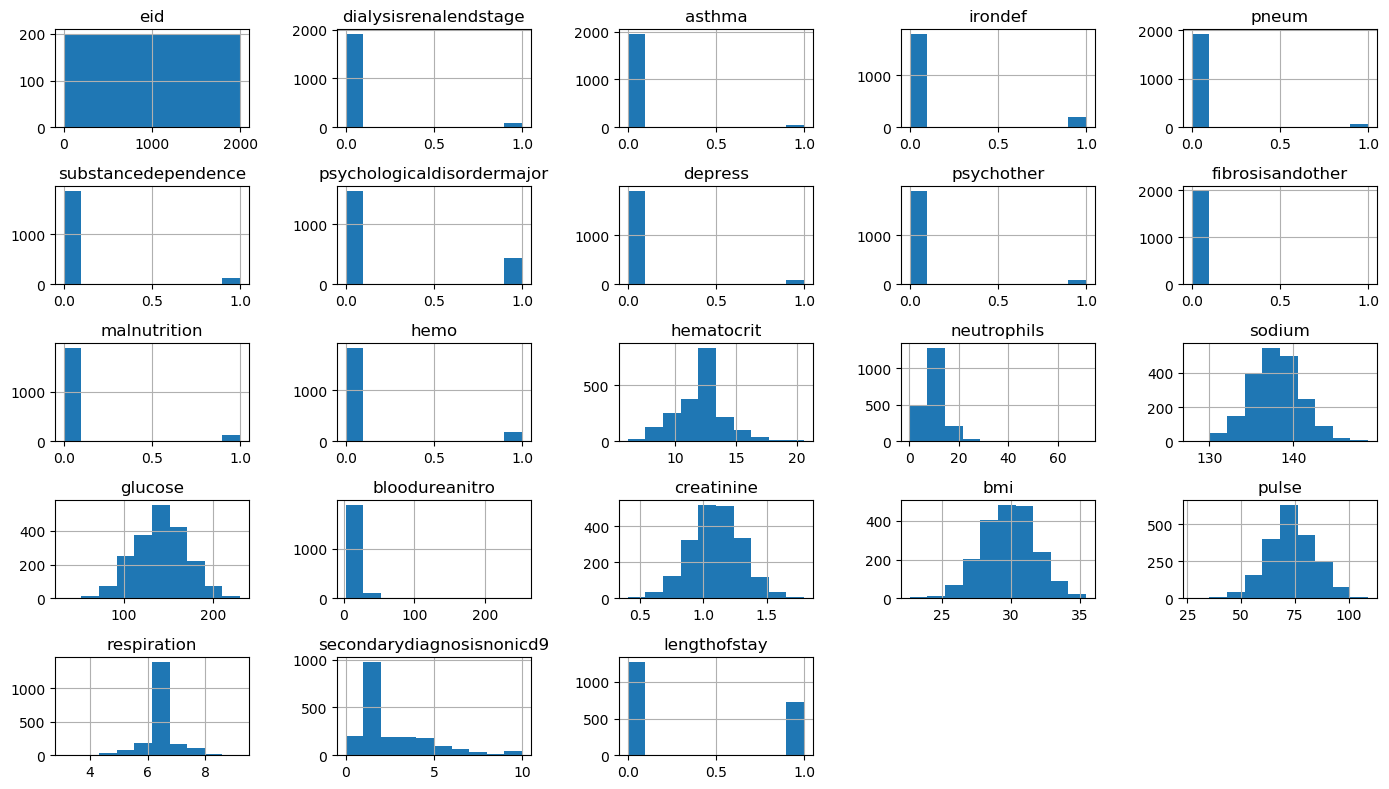

In [4]:
#visualizing distribution of numerical data
dataset.hist(figsize=(14, 8))
plt.title("Representation of Dataset Attributes")
plt.tight_layout()
plt.show()

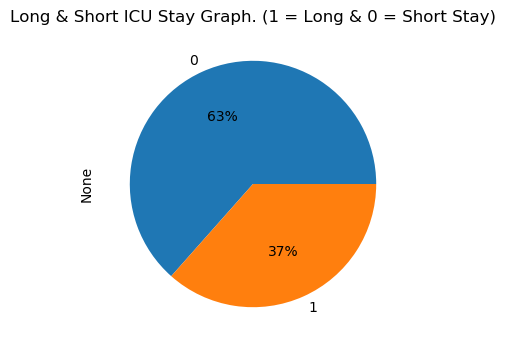

In [5]:
#describe and plotting graph of Long and Short ICU stay 
dataset.groupby("lengthofstay").size().plot.pie(autopct='%.0f%%', figsize=(4, 4))
plt.title("Long & Short ICU Stay Graph. (1 = Long & 0 = Short Stay)")
plt.show()

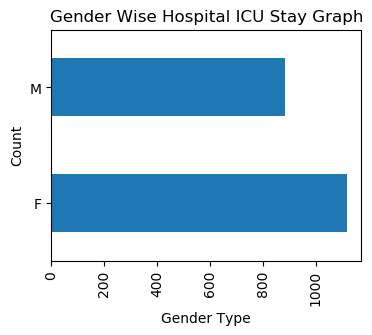

In [6]:
#finding plotting graph of gender wise hospital long and short stay
dataset['gender'].value_counts().plot(kind='barh', figsize=(4, 3))
plt.title("Gender Wise Hospital ICU Stay Graph")
plt.xlabel("Gender Type")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

In [7]:
#dataset pre-processing like converting non-numeric data to numeric data using label encoder class
dataset['vdate'] = pd.to_datetime(dataset['vdate'])
dataset['year'] = dataset['vdate'].dt.year
dataset['month'] = dataset['vdate'].dt.month
dataset['day'] = dataset['vdate'].dt.day
label_encoder = []
columns = dataset.columns
types = dataset.dtypes.values
for i in range(len(types)):
    name = types[i]
    if name == 'object': #finding column with object type
        le = LabelEncoder()
        dataset[columns[i]] = pd.Series(le.fit_transform(dataset[columns[i]].astype(str)))#encode all str columns to numeric
        label_encoder.append([columns[i], le])
Y = dataset['lengthofstay'].ravel()
dataset.drop(['eid', 'vdate','lengthofstay'], axis = 1,inplace=True)#drop ir-relevant columns
print("Cleaned & Processed Dataset")
dataset

Cleaned & Processed Dataset


,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,...,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,year,month,day
0,0,0,0,0,0,0,0,0,0,0,...,1.390722,30.432418,96,6.5,4,342,1,2012,8,29
1,5,0,0,0,0,0,0,0,0,0,...,0.943164,28.460516,61,6.5,1,261,0,2012,5,26
2,1,0,0,0,0,0,0,0,0,0,...,1.065750,28.843812,64,6.5,2,359,1,2012,9,22
3,0,0,0,0,0,0,0,0,0,0,...,0.906862,27.959007,76,6.5,1,312,0,2012,8,9
4,0,0,0,0,0,1,0,1,0,0,...,1.242854,30.258927,67,5.6,2,114,4,2012,12,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,2,1,1,0,1,0,0,0,1,1,...,0.941336,27.621422,60,5.3,1,86,4,2012,11,18
1996,0,1,1,0,0,0,0,0,1,0,...,1.377759,29.148367,70,6.5,1,145,4,2012,2,21
1997,1,0,0,0,0,0,0,0,0,0,...,0.930608,31.128404,85,6.5,3,14,0,2012,1,19
1998,4,0,0,0,0,0,0,0,0,0,...,1.055497,31.732607,89,6.5,6,163,1,2012,3,6


In [8]:
# Define the file path where X will be saved
X_file = 'model/normalized_X.pkl'

# Check if the normalized X file exists
if os.path.exists(X_file):
    # Load the existing normalized X if it already exists
    X = joblib.load(X_file)
    print("Loaded existing normalized training features.")
else:
    # Fill missing values with the column mean
    dataset = dataset.fillna(dataset.mean())

    # Get the columns and the feature values
    columns = dataset.columns
    X = dataset.values

    # Normalize the features using MinMaxScaler
    scaler = MinMaxScaler()
    X = scaler.fit_transform(X)

    # Print normalized training features
    print("Normalized Training Features = " + str(X))
    # Save the normalized X to a file
    joblib.dump(X, X_file)
    print("Normalized training features have been saved.")


Loaded existing normalized training features.


In [9]:
#split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
print("Dataset Train & Test Split Details")
print("80% records used to train algorithms : "+str(X_train.shape[0]))
print("20% records used to test algorithms : "+str(X_test.shape[0]))
data = np.load("model/data.npy", allow_pickle=True)
X_train, X_test, y_train, y_test = data

Dataset Train & Test Split Details
80% records used to train algorithms : 1600
20% records used to test algorithms : 400


In [1]:
#define global variables to save accuracy and other metrics
accuracy = []
precision = []
recall = []
fscore = []
labels = ['Short Stay', 'Long Stay']

ML_Model = []
acc = []
prec = []
rec = []
f1 = []

#function to call for storing the results
def storeResults(model, a,b,c,d):
    ML_Model.append(model)
    acc.append(round(a, 3))
    prec.append(round(b, 3))
    rec.append(round(c, 3))
    f1.append(round(d, 3))

In [11]:
#function to calculate all metrics
def calculateMetrics(algorithm, testY, predict):
    p = precision_score(testY, predict,average='macro') * 100
    r = recall_score(testY, predict,average='macro') * 100
    f = f1_score(testY, predict,average='macro') * 100
    a = accuracy_score(testY,predict)*100
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print(algorithm+" Accuracy  : "+str(a))
    print(algorithm+" Precision : "+str(p))
    print(algorithm+" Recall    : "+str(r))
    print(algorithm+" FSCORE    : "+str(f))
    conf_matrix = confusion_matrix(testY, predict)
    fig, axs = plt.subplots(1,2,figsize=(10, 3))
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="viridis" ,fmt ="g", ax=axs[0]);
    ax.set_ylim([0,len(labels)])
    axs[0].set_title(algorithm+" Confusion matrix") 

    random_probs = [0 for i in range(len(testY))]
    p_fpr, p_tpr, _ = roc_curve(testY, random_probs, pos_label=1)
    plt.plot(p_fpr, p_tpr, linestyle='--', color='orange',label="True classes")
    ns_fpr, ns_tpr, _ = roc_curve(testY, predict, pos_label=1)
    axs[1].plot(ns_fpr, ns_tpr, linestyle='--', label='Predicted Classes')
    axs[1].set_title(algorithm+" ROC AUC Curve")
    axs[1].set_xlabel('False Positive Rate')
    axs[1].set_ylabel('True Positive rate')
    plt.show()  

Loaded existing Logistic Regression model.
Logistic Regression Accuracy  : 89.75
Logistic Regression Precision : 89.66129552992281
Logistic Regression Recall    : 87.37415643323376
Logistic Regression FSCORE    : 88.34225435210656


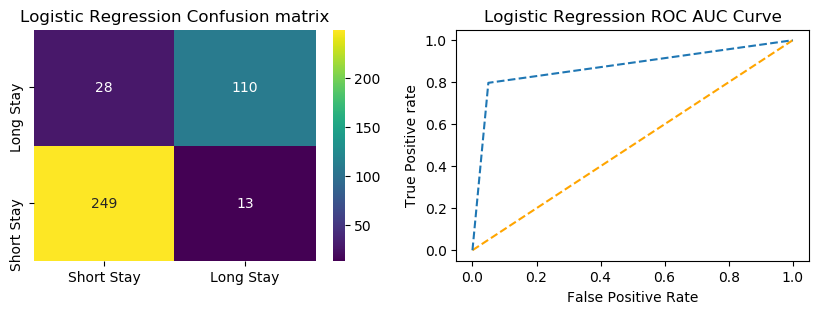

In [12]:
#training logistic regression algorithm using tuning grid search parameters
#defining tuning parameters list
# Define hyperparameters for GridSearchCV
# Define the model file path for saving
model_file = 'model/logistic_regression_model.pkl'

# Check if the model file exists
if os.path.exists(model_file):
    # Load the existing Logistic Regression model if it already exists
    lr_cls = joblib.load(model_file)
    print("Loaded existing Logistic Regression model.")
else:
    # Initialize LogisticRegression
    lr_cls = LogisticRegression()

    # Define hyperparameters for GridSearchCV
    hyperParameters = {'solver': ['liblinear', 'newton-cg'], 'C': [0.001, 0.01, 1]}

    # Initialize GridSearchCV with the Logistic Regression model and hyperparameters
    lr_cls1 = GridSearchCV(lr_cls, hyperParameters, scoring='accuracy')

    # Train the Logistic Regression model with GridSearchCV on the training data
    lr_cls1.fit(X_train, y_train)
    print("Trained new Logistic Regression model with GridSearchCV.")

    # Save the best model from GridSearchCV (best_estimator_) to a file
    joblib.dump(lr_cls1.best_estimator_, model_file)
    print("Logistic Regression model has been saved.")

# Perform prediction on the test data
y_pred = lr_cls.predict(X_test)

# Call the calculateMetrics function to calculate accuracy and other metrics
calculateMetrics("Logistic Regression", y_test, y_pred)

In [2]:
storeResults('LogisticRegression',89.75,89.87,87.74,88.65)

Loaded existing MLP model.
Multilayer Perceptron Accuracy  : 97.0
Multilayer Perceptron Precision : 97.37891737891738
Multilayer Perceptron Recall    : 95.99513220488993
Multilayer Perceptron FSCORE    : 96.63337448097856


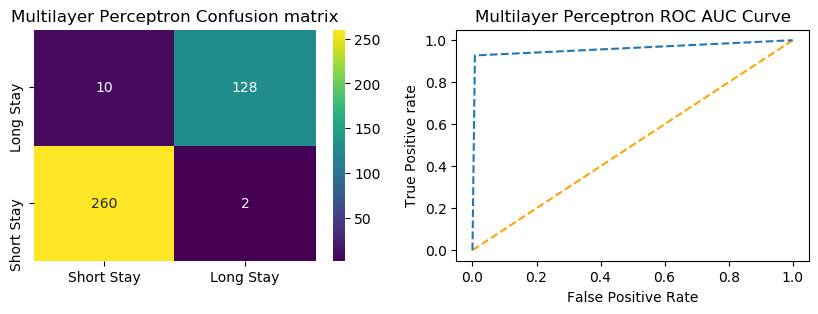

In [13]:
#training MLP algorithm using tuning grid search parameters
#defining tuning parameters list
model_file = 'model/mlp_classifier_model.pkl'

# Define hyperparameters for GridSearchCV
hyperParameters = {
    'learning_rate_init': [0.01], 
    'activation': ['logistic', 'tanh'], 
    'hidden_layer_sizes': [10, 50]
}

# Initialize MLP classifier
mlp_cls = MLPClassifier(max_iter=1000)

# Initialize GridSearchCV with the MLP classifier and hyperparameters
mlp_cls1 = GridSearchCV(mlp_cls, hyperParameters, scoring='accuracy')

# Check if the model file exists
if os.path.exists(model_file):
    # Load the existing MLP model if it already exists
    mlp_cls = joblib.load(model_file)
    print("Loaded existing MLP model.")
else:
    # Train the MLP classifier with GridSearchCV on the training data
    mlp_cls1.fit(X_train, y_train)
    print("Trained new MLP model with GridSearchCV.")

    # Save the best model from GridSearchCV (best_estimator_) to a file
    joblib.dump(mlp_cls1.best_estimator_, model_file)
    print("MLP model has been saved.")

# Perform prediction on the test data
predict = mlp_cls.predict(X_test)

# Call the calculateMetrics function to calculate accuracy and other metrics
calculateMetrics("Multilayer Perceptron", y_test, predict)

In [3]:
storeResults('MLP',97.,97.38,95.99,96.63)

Loaded existing Random Forest model.
Random Forest Accuracy  : 94.5
Random Forest Precision : 95.85286693112153
Random Forest Recall    : 92.2004646531696
Random Forest FSCORE    : 93.68106617647058


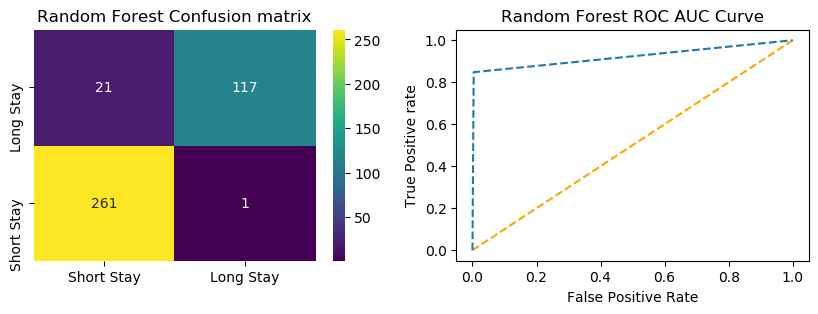

In [14]:
#training Random Forest algorithm using tuning grid search parameters
#defining tuning parameters list
model_file = 'model/random_forest_model.pkl'

# Define hyperparameters for GridSearchCV
hyperParameters = {
    'n_estimators': [5, 50, 250],
    'max_depth': [4, 8],
    'max_features': ['sqrt', 'log2']
}

# Initialize the RandomForestClassifier
rf_cls = RandomForestClassifier(n_estimators=2)

# Initialize GridSearchCV with the Random Forest model and hyperparameters
rf_cls1 = GridSearchCV(rf_cls, hyperParameters, scoring='accuracy')

# Check if the model file exists
if os.path.exists(model_file):
    # Load the existing Random Forest model if it already exists
    rf_cls = joblib.load(model_file)
    print("Loaded existing Random Forest model.")
else:
    # Train the Random Forest classifier with GridSearchCV on the training data
    rf_cls1.fit(X_train, y_train)
    print("Trained new Random Forest model with GridSearchCV.")

    # Save the best model from GridSearchCV (best_estimator_) to a file
    joblib.dump(rf_cls1.best_estimator_, model_file)
    print("Random Forest model has been saved.")

# Perform prediction on the test data
predict = rf_cls.predict(X_test)

# Call the calculateMetrics function to calculate accuracy and other metrics
calculateMetrics("Random Forest", y_test, predict)

In [4]:
storeResults('RandomForest',94.0,95.85,92.20,93.68)

Loaded existing Gradient Boosting model.
Gradient Boosting Accuracy  : 98.0
Gradient Boosting Precision : 98.51851851851852
Gradient Boosting Recall    : 97.10144927536231
Gradient Boosting FSCORE    : 97.75558298731904


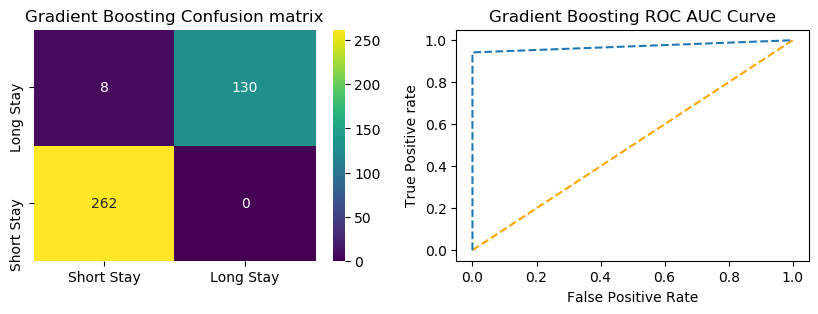

In [15]:
#training Gradient Boosting algorithm using tuning grid search parameters
#defining tuning parameters list
model_file = 'model/gradient_boosting_model.pkl'

# Define hyperparameters for GridSearchCV
hyperParameters = {
    'n_estimators': [5, 50, 500],
    'max_depth': [1, 5, 9],
    'learning_rate': [0.01]
}

# Initialize the GradientBoostingClassifier
gb_cls = GradientBoostingClassifier(n_estimators=50)

# Initialize GridSearchCV with the Gradient Boosting model and hyperparameters
gb_cls1 = GridSearchCV(gb_cls, hyperParameters, scoring='accuracy')

# Check if the model file exists
if os.path.exists(model_file):
    # Load the existing Gradient Boosting model if it already exists
    gb_cls = joblib.load(model_file)
    print("Loaded existing Gradient Boosting model.")
else:
    # Train the Gradient Boosting classifier with GridSearchCV on the training data
    gb_cls1.fit(X_train, y_train)
    print("Trained new Gradient Boosting model with GridSearchCV.")

    # Save the best model from GridSearchCV (best_estimator_) to a file
    joblib.dump(gb_cls1.best_estimator_, model_file)
    print("Gradient Boosting model has been saved.")

# Perform prediction on the test data
predict = gb_cls.predict(X_test)

# Call the calculateMetrics function to calculate accuracy and other metrics
calculateMetrics("Gradient Boosting", y_test, predict)

In [5]:
storeResults('GradientBoosting',98,98.52,97.10,97.76)

Loaded existing XGBoost model.
XGBoost Accuracy  : 98.25
XGBoost Precision : 98.50046464475795
XGBoost Recall    : 97.63524726186526
XGBoost FSCORE    : 98.04686137598615


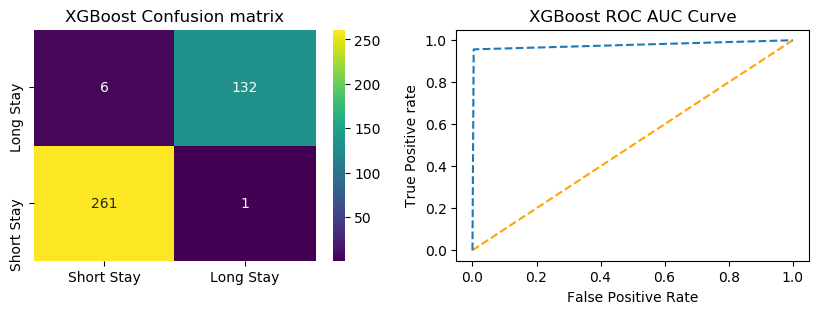

In [16]:
#training XGBoost algorithm using tuning grid search parameters
#defining tuning parameters list
model_file = 'model/xgboost_model.pkl'

# Define hyperparameters for GridSearchCV
hyperParameters = {
    'n_estimators': [5, 100, 250],
    'max_depth': [1, 3, 5],
    'learning_rate': [0.01, 0.1, 1]
}

# Initialize the XGBClassifier
xg_cls = XGBClassifier(n_estimators=10)

# Initialize GridSearchCV with the XGBoost model and hyperparameters
xg_cls1 = GridSearchCV(xg_cls, hyperParameters, scoring='accuracy')

# Check if the model file exists
if os.path.exists(model_file):
    # Load the existing XGBoost model if it already exists
    xg_cls = joblib.load(model_file)
    print("Loaded existing XGBoost model.")
else:
    # Train the XGBoost classifier with GridSearchCV on the training data
    xg_cls1.fit(X_train, y_train)
    print("Trained new XGBoost model with GridSearchCV.")

    # Save the best model from GridSearchCV (best_estimator_) to a file
    joblib.dump(xg_cls1.best_estimator_, model_file)
    print("XGBoost model has been saved.")

# Perform prediction on the test data
predict = xg_cls.predict(X_test)

# Call the calculateMetrics function to calculate accuracy and other metrics
calculateMetrics("XGBoost", y_test, predict)

In [6]:
storeResults('XGBoost',98.25,98.5,97.64,98.04)

Loaded existing CatBoost model.
Extension CatBoost Accuracy  : 99.5
Extension CatBoost Precision : 99.62121212121212
Extension CatBoost Recall    : 99.27536231884058
Extension CatBoost FSCORE    : 99.4449224279093


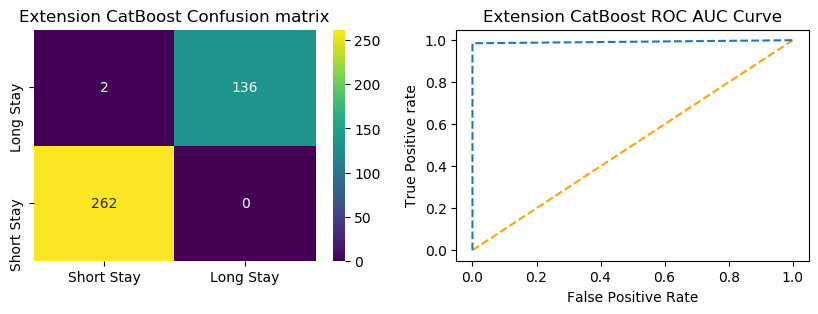

In [17]:
#training CatBoost algorithm on tuning parameters
model_file = 'model/catboost_model.pkl'

# Initialize the CatBoostClassifier with specified parameters
extension_model = CatBoostClassifier(iterations=10000)

# Check if the model file exists
if os.path.exists(model_file):
    # Load the existing CatBoost model if it already exists
    extension_model = CatBoostClassifier()
    extension_model.load_model(model_file)
    print("Loaded existing CatBoost model.")
else:
    # Train the CatBoost model on the training data
    extension_model.fit(X_train, y_train)
    print("Trained new CatBoost model.")

    # Save the trained CatBoost model to a file
    extension_model.save_model(model_file)
    print("CatBoost model has been saved.")

# Perform prediction on the test data
predict = extension_model.predict(X_test)

# Call the calculateMetrics function to calculate accuracy and other metrics
calculateMetrics("Extension CatBoost", y_test, predict)

In [7]:
storeResults('Extension',99.5,99.62,99.27,99.44)

# Comparison

In [19]:
#display all algorithm performnace
algorithms = ['Logistic Regression', 'MLP', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'Extension CatBoost']
data = []
for i in range(len(accuracy)):
    data.append([algorithms[i], accuracy[i], precision[i], recall[i], fscore[i]])
data = pd.DataFrame(data, columns=['Algorithm Name', 'Accuracy', 'Precision', 'Recall', 'FSCORE'])
data  

,Algorithm Name,Accuracy,Precision,Recall,FSCORE
0,Logistic Regression,89.75,89.661296,87.374156,88.342254
1,MLP,97.00,97.378917,95.995132,96.633374
2,Random Forest,94.50,95.852867,92.200465,93.681066
3,Gradient Boosting,98.00,98.518519,97.101449,97.755583
4,XGBoost,98.25,98.500465,97.635247,98.046861
5,Extension CatBoost,99.50,99.621212,99.275362,99.444922


# Graph

In [8]:
import numpy as np
classifier = ML_Model
y_pos = np.arange(len(classifier))

# Accuracy

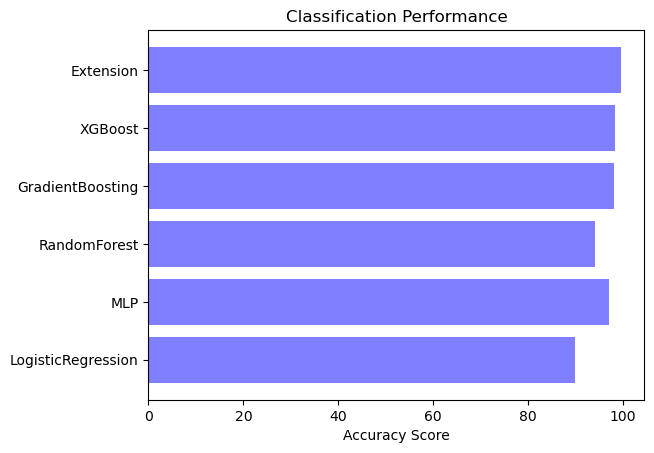

In [9]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, acc, align='center', alpha=0.5,color='blue')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Accuracy Score')
plt2.title('Classification Performance')
plt2.show()

# Precision

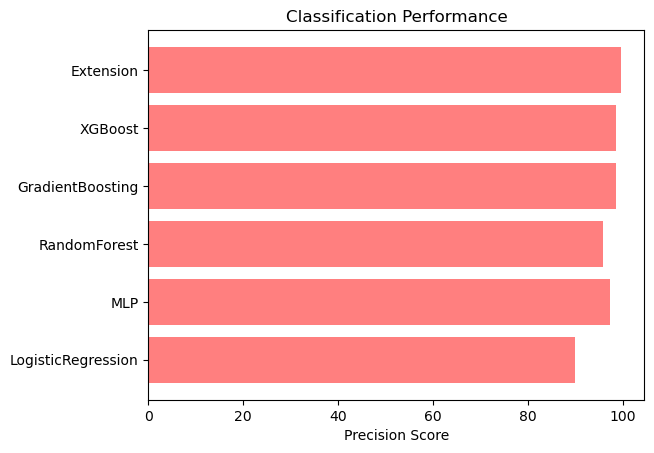

In [10]:
plt2.barh(y_pos, prec, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

# Recall

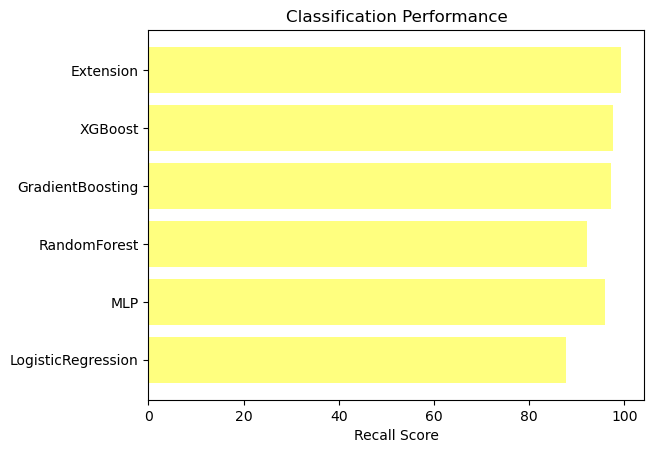

In [11]:
plt2.barh(y_pos, rec, align='center', alpha=0.5,color='yellow')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Recall Score')
plt2.title('Classification Performance')
plt2.show()

# F1 Score

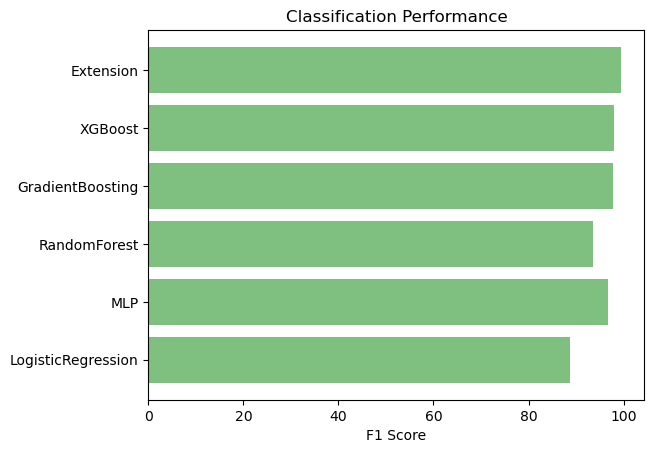

In [12]:
plt2.barh(y_pos, f1, align='center', alpha=0.5,color='green')
plt2.yticks(y_pos, classifier)
plt2.xlabel('F1 Score')
plt2.title('Classification Performance')
plt2.show()